In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.datasets import make_classification

In [3]:
?make_classification

Signature:
make_classification(
    n_samples=100,
    n_features=20,
    *,
    n_informative=2,
    n_redundant=2,
    n_repeated=0,
    n_classes=2,
    n_clusters_per_class=2,
    weights=None,
    flip_y=0.01,
    class_sep=1.0,
    hypercube=True,
    shift=0.0,
    scale=1.0,
    shuffle=True,
    random_state=None,
)
Docstring:
Generate a random n-class classification problem.

This initially creates clusters of points normally distributed (std=1)
about vertices of an ``n_informative``-dimensional hypercube with sides of
length ``2*class_sep`` and assigns an equal number of clusters to each
class. It introduces interdependence between these features and adds
various types of further noise to the data.

Without shuffling, ``X`` horizontally stacks features in the following
order: the primary ``n_informative`` features, followed by ``n_redundant``
linear combinations of the informative features, followed by ``n_repeated``
duplicates, drawn randomly with replacement from the infor

In [30]:
def make_data(sep):

    X, y = make_classification(n_samples=1000,
                               n_features=2,
                               n_redundant=0,
                               n_clusters_per_class=1,
                               weights=[.75],
                               class_sep = sep,
                               random_state=0)
    
    X = pd.DataFrame(X, columns=['varA', 'varB'])
    y = pd.Series(y)

    return X,y

# Undersampling with Tomek Links

In [31]:
import imblearn.under_sampling

In [32]:
dir(imblearn.under_sampling)

['AllKNN',
 'ClusterCentroids',
 'CondensedNearestNeighbour',
 'EditedNearestNeighbours',
 'InstanceHardnessThreshold',
 'NearMiss',
 'NeighbourhoodCleaningRule',
 'OneSidedSelection',
 'RandomUnderSampler',
 'RepeatedEditedNearestNeighbours',
 'TomekLinks',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_prototype_generation',
 '_prototype_selection',
 'base']

In [33]:
from imblearn.under_sampling import TomekLinks

In [34]:
?TomekLinks

Init signature: TomekLinks(*, sampling_strategy='auto', n_jobs=None)
Docstring:     
Under-sampling by removing Tomek's links.

Read more in the :ref:`User Guide <tomek_links>`.

Parameters
----------
sampling_strategy : str, list or callable
    Sampling information to sample the data set.

    - When ``str``, specify the class targeted by the resampling. Note the
      the number of samples will not be equal in each. Possible choices
      are:

        ``'majority'``: resample only the majority class;

        ``'not minority'``: resample all classes but the minority class;

        ``'not majority'``: resample all classes but the majority class;

        ``'all'``: resample all classes;

        ``'auto'``: equivalent to ``'not minority'``.

    - When ``list``, the list contains the classes targeted by the
      resampling.

    - When callable, function taking ``y`` and returns a ``dict``. The keys
      correspond to the targeted classes. The values correspond to the
      desir

In [41]:
X, y = make_data(sep=1)

tl = TomekLinks(
    sampling_strategy='auto',
    n_jobs=-1
)

X_resampled, y_resampled = tl.fit_resample(X,y)

In [42]:
X.shape, y.shape

((1000, 2), (1000,))

In [43]:
X_resampled.shape, y_resampled.shape

((975, 2), (975,))

Text(0.5, 1.0, 'Tomek Links Resampled Data')

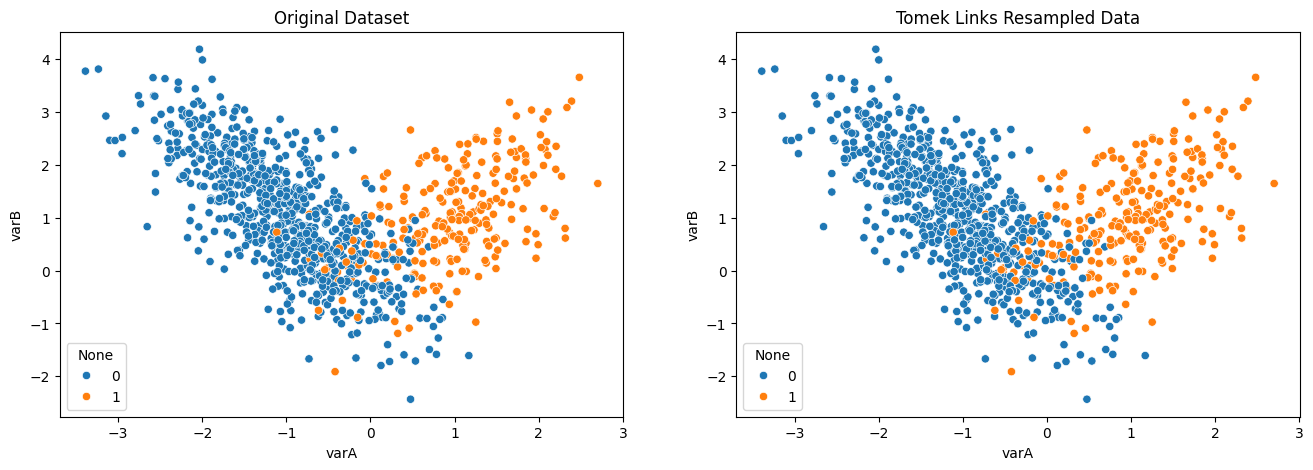

In [44]:
plt.figure(figsize=(16,5))
plt.subplot(121)
sns.scatterplot(x='varA', y='varB', data=X, hue=y)
plt.title('Original Dataset')

plt.subplot(122)
sns.scatterplot(x='varA', y='varB', data=X_resampled, hue=y_resampled)
plt.title('Tomek Links Resampled Data')

In [45]:
dir(imblearn.under_sampling)

['AllKNN',
 'ClusterCentroids',
 'CondensedNearestNeighbour',
 'EditedNearestNeighbours',
 'InstanceHardnessThreshold',
 'NearMiss',
 'NeighbourhoodCleaningRule',
 'OneSidedSelection',
 'RandomUnderSampler',
 'RepeatedEditedNearestNeighbours',
 'TomekLinks',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_prototype_generation',
 '_prototype_selection',
 'base']

In [46]:
?TomekLinks

Init signature: TomekLinks(*, sampling_strategy='auto', n_jobs=None)
Docstring:     
Under-sampling by removing Tomek's links.

Read more in the :ref:`User Guide <tomek_links>`.

Parameters
----------
sampling_strategy : str, list or callable
    Sampling information to sample the data set.

    - When ``str``, specify the class targeted by the resampling. Note the
      the number of samples will not be equal in each. Possible choices
      are:

        ``'majority'``: resample only the majority class;

        ``'not minority'``: resample all classes but the minority class;

        ``'not majority'``: resample all classes but the majority class;

        ``'all'``: resample all classes;

        ``'auto'``: equivalent to ``'not minority'``.

    - When ``list``, the list contains the classes targeted by the
      resampling.

    - When callable, function taking ``y`` and returns a ``dict``. The keys
      correspond to the targeted classes. The values correspond to the
      desir

In [48]:
dir(TomekLinks)

['__abstractmethods__',
 '__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__sklearn_clone__',
 '__sklearn_tags__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_build_request_for_signature',
 '_check_X_y',
 '_check_feature_names',
 '_check_n_features',
 '_doc_link_module',
 '_doc_link_template',
 '_doc_link_url_param_generator',
 '_estimator_type',
 '_fit_resample',
 '_get_default_requests',
 '_get_doc_link',
 '_get_metadata_request',
 '_get_param_names',
 '_get_tags',
 '_more_tags',
 '_parameter_constraints',
 '_repr_html_',
 '_repr_html_inner',
 '_repr_mimebundle_',
 '_sampling_strategy_docstring',
 '_sampling_type',
 '_validate_data',
 '_vali

In [49]:
X, y = make_data(sep=0.5)

tl = TomekLinks(sampling_strategy='auto', n_jobs=-1)
X_resampled2, y_resampled2 = tl.fit_resample(X, y)

In [51]:
X.shape, X_resampled2.shape

((1000, 2), (945, 2))

Text(0.5, 1.0, "TomekLink's Resampled Data")

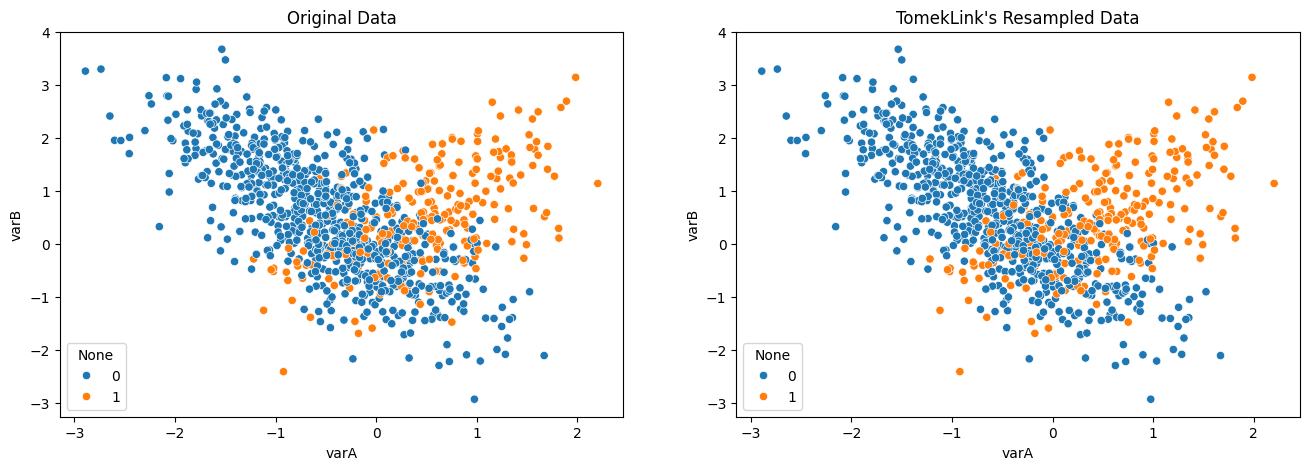

In [50]:
plt.figure(figsize=(16,5))
plt.subplot(121)
sns.scatterplot(x='varA', y='varB', data=X, hue=y)
plt.title('Original Data')

plt.subplot(122)
sns.scatterplot(x='varA', y='varB', data=X_resampled2, hue=y_resampled2)
plt.title("TomekLink's Resampled Data")

In [52]:
?TomekLinks

Init signature: TomekLinks(*, sampling_strategy='auto', n_jobs=None)
Docstring:     
Under-sampling by removing Tomek's links.

Read more in the :ref:`User Guide <tomek_links>`.

Parameters
----------
sampling_strategy : str, list or callable
    Sampling information to sample the data set.

    - When ``str``, specify the class targeted by the resampling. Note the
      the number of samples will not be equal in each. Possible choices
      are:

        ``'majority'``: resample only the majority class;

        ``'not minority'``: resample all classes but the minority class;

        ``'not majority'``: resample all classes but the majority class;

        ``'all'``: resample all classes;

        ``'auto'``: equivalent to ``'not minority'``.

    - When ``list``, the list contains the classes targeted by the
      resampling.

    - When callable, function taking ``y`` and returns a ``dict``. The keys
      correspond to the targeted classes. The values correspond to the
      desir

In [57]:
X,y =make_data(sep=0.01)

tl = TomekLinks(sampling_strategy='auto', n_jobs=-1)
X_resampled3, y_resampled3 = tl.fit_resample(X,y)

In [58]:
X.shape, X_resampled3.shape


((1000, 2), (912, 2))

<Axes: xlabel='varA', ylabel='varB'>

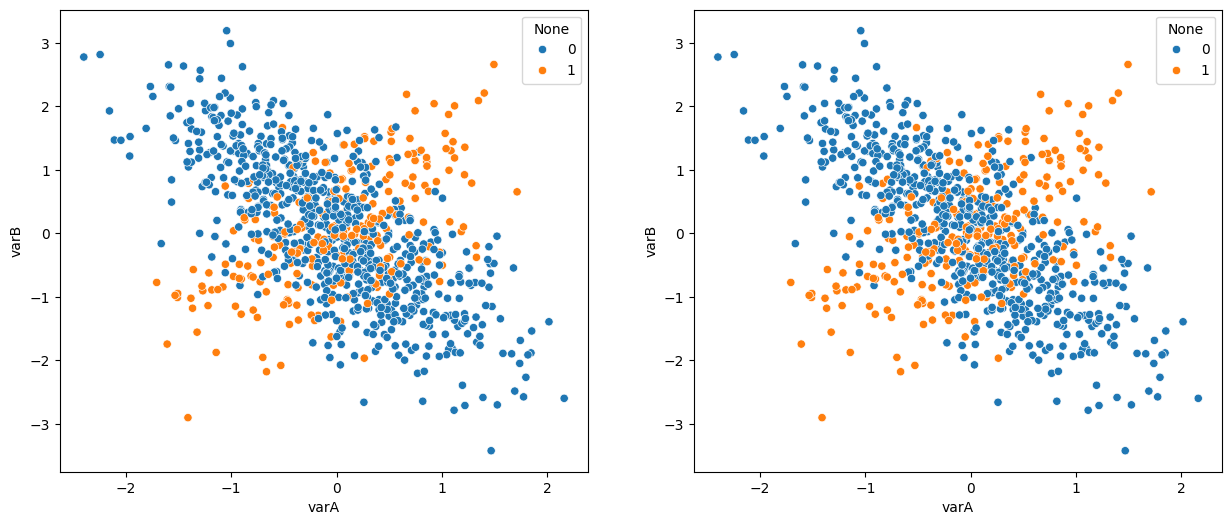

In [59]:
plt.figure(figsize=(15,6))
plt.subplot(121)
sns.scatterplot(x='varA', y='varB', data=X, hue=y)

plt.subplot(122)
sns.scatterplot(x='varA', y='varB', data=X_resampled3, hue=y_resampled3)